## Project: 멋진 챗봇 만들기

### 0. 환경 구성

In [4]:
!pip install kiwipiepy
!pip install sentencepiece
!pip install nltk
!pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 76.0 MB/s  0:00:01m0:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 70.0 MB/s  0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578163 sha256=3b788e84ca2ccebfc79674949b90f41220ba44ce427d6254d1a1dd633696d29b
  Stored in directory: /home/jovyan/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kiwipiepy]/2 [kiwipiepy]


In [5]:
# =========================================
# 0. 환경 설정 & 라이브러리 임포트
# =========================================
import os
import re
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from kiwipiepy import Kiwi            # 형태소 분석기 (mecab 대체)
import sentencepiece as spm
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from transformers import get_cosine_schedule_with_warmup

import matplotlib.pyplot as plt       
import seaborn as sns

import matplotlib as mpl
from matplotlib import font_manager
import platform
import os

import warnings


In [6]:

warnings.filterwarnings(
    "ignore",
    message="Glyph 9601",
    module="seaborn.utils"
)
warnings.filterwarnings(
    "ignore",
    message="Glyph 9601",
    module="IPython.core.pylabtools"
)

system = platform.system()

if system == "Windows":
    mpl.rcParams["font.family"] = "Malgun Gothic"  # 윈도우 기본 한글 폰트
elif system == "Darwin":
    mpl.rcParams["font.family"] = "AppleGothic"
else:
    # 기타 별도 설치
    pass

mpl.rcParams["axes.unicode_minus"] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [7]:
# 재현성 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    

### 1. 데이터 적재 및 전처리

In [8]:
# =========================================
# 1. 데이터 로드 & 전처리 (Chatbot_data.csv)
#    - songys/Chatbot_data 사용
# =========================================
DATA_PATH = "./data/ChatbotData.csv"  # 경로에 맞게 수정
assert os.path.exists(DATA_PATH), "Chatbot_data.csv 준비 필요!"

df = pd.read_csv(DATA_PATH)
# 컬럼: Q(질문), A(답변), label 등으로 되어 있음
df = df[["Q", "A"]].dropna()

print("원본 데이터 개수:", len(df))

원본 데이터 개수: 11823


In [9]:
# -----------------------------------------
# 1-1. 한글 정규화 & 기본 전처리 함수
# -----------------------------------------
def clean_korean_text(text: str) -> str:
    text = str(text).strip()
    # 자모 분리/이상한 문자 제거 등 간단 처리
    text = re.sub(r"[^ㄱ-ㅎ가-힣0-9a-zA-Z\?\!\.\,\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Q_clean"] = df["Q"].apply(clean_korean_text)
df["A_clean"] = df["A"].apply(clean_korean_text)

# 너무 짧거나 긴 문장 제거
df = df[(df["Q_clean"].str.len() >= 2) & (df["Q_clean"].str.len() <= 50)]
df = df[(df["A_clean"].str.len() >= 2) & (df["A_clean"].str.len() <= 50)]

print("1차 정제 후 개수:", len(df))

1차 정제 후 개수: 11787


### 2. 형태소 분석 및 토큰 수준 정제

In [10]:
# =========================================
# 2. 형태소 분석 + 토큰 수준 정제 (Kiwi)
#    - mecab 대신 Kiwi 사용
# =========================================
kiwi = Kiwi()

def kiwi_tokenize(text: str):
    # 간단히 명사/동사/형용사 위주로 사용 (원하면 품사 필터링 조정)
    tokens = []
    for tok, pos, _, _ in kiwi.analyze(text, top_n=1)[0][0]:
        if pos.startswith("NN") or pos.startswith("VV") or pos.startswith("VA") or pos.startswith("MAG") or pos.startswith("IC"):
            tokens.append(tok)
        else:
            # 조사/어미 등도 포함하고 싶으면 주석 해제
            tokens.append(tok)
            pass
    # 토큰이 너무 적으면 원문 그대로 fallback
    if len(tokens) < 2:
        return text.split()
    return tokens

def join_tokens(tokens):
    return " ".join(tokens)

df["Q_tok"] = df["Q_clean"].apply(kiwi_tokenize)
df["A_tok"] = df["A_clean"].apply(kiwi_tokenize)

# 토큰 리스트를 다시 공백 기준 문장으로 변환 (SentencePiece 학습용)
df["Q_proc"] = df["Q_tok"].apply(join_tokens)
df["A_proc"] = df["A_tok"].apply(join_tokens)

print("토큰 예시 Q:", df["Q_proc"].iloc[0])
print("토큰 예시 A:", df["A_proc"].iloc[0])

토큰 예시 Q: 12 시 땡 !
토큰 예시 A: 하루 가 또 가 네요 .


### 3. 데이터 증강

In [11]:
# =========================================
# 3. 데이터 증강 (augmentation)
#    - 간단한 방식: 역질문 추가, 일부 단어 드랍, 순서 스왑 등
#    - 목표: 약 3만 문장 쌍 (질문-답변) 확보
# =========================================
pairs = list(zip(df["Q_proc"].tolist(), df["A_proc"].tolist()))
print("원본 쌍 개수:", len(pairs))

def random_drop_tokens(tokens, drop_prob=0.05):
    if len(tokens) <= 3:
        return tokens
    new_tokens = []
    for t in tokens:
        if random.random() < drop_prob:
            continue
        new_tokens.append(t)
    if len(new_tokens) < 2:
        return tokens
    return new_tokens

def random_swap_tokens(tokens, swap_prob=0.05):
    tokens = tokens[:]
    n = len(tokens)
    for i in range(n - 1):
        if random.random() < swap_prob:
            j = min(n - 1, i + 1)
            tokens[i], tokens[j] = tokens[j], tokens[i]
    return tokens

aug_pairs = []

for q, a in pairs:
    aug_pairs.append((q, a))  # 원본

    # 1) Q 토큰 드랍
    q_toks = q.split()
    a_toks = a.split()
    q_drop = " ".join(random_drop_tokens(q_toks))
    aug_pairs.append((q_drop, a))

    # 2) A 토큰 드랍
    a_drop = " ".join(random_drop_tokens(a_toks))
    aug_pairs.append((q, a_drop))

    # 3) Q/A 둘 다 스왑
    q_swap = " ".join(random_swap_tokens(q_toks))
    a_swap = " ".join(random_swap_tokens(a_toks))
    aug_pairs.append((q_swap, a_swap))

# 중복 제거
aug_pairs = list(set(aug_pairs))
print("증강 후 쌍 개수:", len(aug_pairs))

# 3만 개 가까이 맞추기 (필요시 샘플링)
TARGET_SIZE = 30000
if len(aug_pairs) > TARGET_SIZE:
    aug_pairs = random.sample(aug_pairs, TARGET_SIZE)

print("최종 사용 쌍 개수:", len(aug_pairs))

원본 쌍 개수: 11787
증강 후 쌍 개수: 25999
최종 사용 쌍 개수: 25999


### 4. 토크나이저 학습

In [12]:
# =========================================
# 4. SentencePiece 토크나이저 학습 (공용 vocab)
#    - generatetokenizer 패턴
# =========================================
SPM_MODEL_PREFIX = "chatbot_spm"
VOCAB_SIZE = 2774  # 과적합 방지를 위해 너무 크지 않게

# 학습용 코퍼스 파일 생성
corpus_file = "chatbot_corpus.txt"
with open(corpus_file, "w", encoding="utf-8") as f:
    for q, a in aug_pairs:
        f.write(q + "\n")
        f.write(a + "\n")

spm.SentencePieceTrainer.Train(
    f"--input={corpus_file} "
    f"--model_prefix={SPM_MODEL_PREFIX} "
    f"--vocab_size={VOCAB_SIZE} "
    f"--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3"
)
tokenizer = spm.SentencePieceProcessor()
tokenizer.Load(f"{SPM_MODEL_PREFIX}.model")
print("Vocab size:", tokenizer.GetPieceSize())

Vocab size: 2779


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=chatbot_corpus.txt --model_prefix=chatbot_spm --vocab_size=2779 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: chatbot_corpus.txt
  input_format: 
  model_prefix: chatbot_spm
  model_type: UNIGRAM
  vocab_size: 2779
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0

### 5. 토큰화 + 패딩 텐서 생성

In [13]:
# =========================================
# 5. 토큰화 + 패딩 텐서 생성
#    - padSequencesCustom 형태
# =========================================
MAX_LEN = 40  # 챗봇이니 너무 길지 않게
def encode_sentence(text):
    ids = tokenizer.EncodeAsIds(text)
    # BOS=1, EOS=2 직접 붙이기
    return [1] + ids + [2]

src_corpus = []
tgt_corpus = []

for q, a in tqdm(aug_pairs, desc="Encoding"):
    q_ids = encode_sentence(q)
    a_ids = encode_sentence(a)
    if len(q_ids) > MAX_LEN or len(a_ids) > MAX_LEN:
        continue
    src_corpus.append(q_ids)
    tgt_corpus.append(a_ids)

print("길이 제한 후 쌍 개수:", len(src_corpus))

def pad_sequences(seqs, maxlen, pad_value=0):
    padded = []
    for s in seqs:
        if len(s) > maxlen:
            s = s[:maxlen]
        padded.append(s + [pad_value] * (maxlen - len(s)))
    return torch.tensor(padded, dtype=torch.long)

enc_ndarray = pad_sequences(src_corpus, MAX_LEN, pad_value=0)
dec_ndarray = pad_sequences(tgt_corpus, MAX_LEN, pad_value=0)
print("enc shape:", enc_ndarray.shape)
print("dec shape:", dec_ndarray.shape)

dataset = TensorDataset(enc_ndarray, dec_ndarray)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True, pin_memory=True)

Encoding: 100%|██████████| 25999/25999 [00:00<00:00, 36822.02it/s]


길이 제한 후 쌍 개수: 25996
enc shape: torch.Size([25996, 40])
dec shape: torch.Size([25996, 40])


### 6. Transformer 모델 정의

In [14]:
# =========================================
# 6. Transformer 모델 정의
#    - 과적합 방지: dropout, shared embedding, warmup lr
# =========================================
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Q,K,V: (B, H, L, D)
        dk = K.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(dk)  # (B,H,L,L)
        if mask is not None:
            # mask: (B,1,L,L) with 0 or 1 -> 1 is masked
            scores = scores.masked_fill(mask == 1, -1e9)
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, V)
        return out, attn

    def split_heads(self, x):
        # x: (B, L, D) -> (B, H, L, depth)
        B, L, D = x.size()
        x = x.view(B, L, self.num_heads, self.depth).permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        # x: (B, H, L, depth) -> (B, L, D)
        B, H, L, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous().view(B, L, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        # Q,K,V: (B, L, D)
        Q = self.Wq(Q)
        K = self.Wk(K)
        V = self.Wv(V)

        Qh = self.split_heads(Q)
        Kh = self.split_heads(K)
        Vh = self.split_heads(V)

        out, attn = self.scaled_dot_product_attention(Qh, Kh, Vh, mask)
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attn


In [15]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # self-attention
        residual = x
        x = self.norm1(x)
        x, attn = self.self_attn(x, x, x, mask)
        x = self.dropout(x)
        x = x + residual

        # FFN
        residual = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + residual
        return x, attn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.encdec_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_mask, encdec_mask):
        # masked self-attention
        residual = x
        x = self.norm1(x)
        x, self_attn = self.self_attn(x, x, x, dec_mask)
        x = self.dropout(x)
        x = x + residual

        # encoder-decoder attention
        residual = x
        x = self.norm2(x)
        x, encdec_attn = self.encdec_attn(x, enc_out, enc_out, encdec_mask)
        x = self.dropout(x)
        x = x + residual

        # FFN
        residual = x
        x = self.norm3(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + residual

        return x, self_attn, encdec_attn


In [16]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, mask):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            attns.append(attn)
        return x, attns

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_mask, encdec_mask):
        attns = []
        encdec_attns = []
        for layer in self.layers:
            x, sa, ea = layer(x, enc_out, dec_mask, encdec_mask)
            attns.append(sa)
            encdec_attns.append(ea)
        return x, attns, encdec_attns

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, 2 * (i // 2) / d_model)
    sinusoid = np.array([[cal_angle(p, i) for i in range(d_model)] for p in range(pos)])
    sinusoid[:, 0::2] = np.sin(sinusoid[:, 0::2])
    sinusoid[:, 1::2] = np.cos(sinusoid[:, 1::2])
    return sinusoid


In [17]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 max_len,
                 dropout=0.3,
                 shared_emb=True,
                 shared_fc=True):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        pe = positional_encoding(max_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pe, dtype=torch.float32))

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.shared_fc = shared_fc
        if shared_fc:
            self.fc.weight = self.dec_emb.weight

        self.dropout = nn.Dropout(dropout)

    def embed(self, emb, x):
        # x: (B, L)
        B, L = x.size()
        out = emb(x) * math.sqrt(self.d_model)
        pe = self.pos_encoding[:L].unsqueeze(0).to(out.device)
        out = out + pe
        out = self.dropout(out)
        return out

    def forward(self, src, tgt_in, enc_mask, dec_mask, encdec_mask):
        enc_in = self.embed(self.enc_emb, src)
        dec_in = self.embed(self.dec_emb, tgt_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)
        dec_out, dec_attns, decenc_attns = self.decoder(dec_in, enc_out, dec_mask, encdec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, decenc_attns

### 7. 마스크 생성

In [24]:
# =========================================
# 7. 마스크 생성 함수 + Attention 시각화
# =========================================
def generate_padding_mask(seq):
    # seq: (B,L) -> (B,1,1,L) 1 = pad
    mask = (seq == 0).unsqueeze(1).unsqueeze(2)
    return mask  # float/byte 상관 없이 0/1

def generate_causal_mask(size):
    # 상삼각 1 (미래 마스크)
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask  # (L,L) 1 = mask

def generate_masks(src, tgt_in):
    enc_mask = generate_padding_mask(src)                # (B,1,1,S)
    dec_padding = generate_padding_mask(tgt_in)          # (B,1,1,T)
    L = tgt_in.size(1)
    causal = generate_causal_mask(L).to(src.device)      # (L,L)
    causal = causal.unsqueeze(0).unsqueeze(1)            # (1,1,L,L)
    dec_mask = torch.max(dec_padding, causal)            # (B,1,L,L)

    # enc-dec mask: src padding만 고려 (B,1,1,S) broadcasting
    encdec_mask = enc_mask
    return enc_mask, dec_mask, encdec_mask

In [25]:
# =========================================
# 7-1. Attention 시각화 함수
# =========================================
def visualize_attention(src_tokens, tgt_tokens, enc_attns, dec_attns, decenc_attns, layer=0, head=0):
    """
    Transformer의 Cross-Attention을 히트맵으로 시각화합니다.
    """
    # [수정] 매개변수로 받은 layer와 head를 사용하도록 변경 (내부 하드코딩 제거)
    # decenc_attns 크기: [n_layers, Batch, Head, T_len, S_len]
    # layer = 0
    # head = 0
    attn = decenc_attns[layer][0, head].detach().cpu().numpy()  # (L_tgt, L_src)

    # 패딩(<pad>)이 아닌 실제 토큰 길이만 사용
    # [개선] SentencePiece의 특수 문자 ' '를 실제 공백으로 치환하여 한글 깨짐 방지
    # t.replace(' ', ' ') 과정이 없으면 Glyph 9601 경고가 발생하며 사각형으로 표시됨
    
    def effective_len(tokens):
        # return len([t for t in tokens if t != "<pad>"])
        # 1. 문자열 변환 2. SP 특수문자 제거 3. 패딩 제거
        return [t.replace(' ', ' ') if hasattr(t, 'replace') else str(t) for t in tokens if t != "<pad>"]

    src_len = effective_len(src_tokens)
    tgt_len = effective_len(tgt_tokens)

    # 유효 데이터 크기에 맞춰 자르기
    attn = attn[:len(tgt_len), :len(src_len)]
    src_tokens = src_tokens[:len(src_len)]
    tgt_tokens = tgt_tokens[:len(tgt_len)]

    plt.figure(figsize=(8, 6))
    sns.heatmap(  # 기존 'ax'변수가 사용되지 않음
        attn,
        xticklabels=src_tokens,
        yticklabels=tgt_tokens,
        square=True,
        cmap="Blues",
        vmin=0.0, vmax=1.0,
    )
    plt.xlabel("Source")
    plt.ylabel("Target")
    plt.title(f"Enc-Dec Attention (Layer {layer+1}, Head {head+1})")
    # [수정] 한글 레이블이 잘 보이지 않을 경우 대비하여 레이아웃 최적화
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### 8. 학습 준비

In [20]:
# =========================================
# 8. 하이퍼파라미터 Optimizer, Loss
# =========================================
d_model = 256           # 임베딩 및 은닉층 차원 (연산 효율을 위해 가볍게 설정)
n_layers = 2            # 인코더/디코더 레이어 쌓는 횟수
n_heads = 8             # 멀티헤드 어텐션의 헤드 수 (256이 8로 나누어 떨어져야 함)
d_ff = 4 * d_model      # Feed-Forward 네트워크의 중간 층 차원 (보통 d_model의 4배)
dropout = 0.1           # 훈련 중 뉴런을 끄는 비율 (0.3에서 0.1로 낮추어 과한 regularization로 인한 정보 손실 완화)
EPOCHS = 10             # 전체 데이터 학습 반복 횟수

# 모델 인스턴스 생성 및 GPU/CPU 장치 이동
model = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    dropout=dropout,
    shared_emb=True,    # 인코더-디코더 임베딩 공유 (한국어-한국어 챗봇에 유리)
    shared_fc=True      # 출력층 가중치 공유 (Weight Tying으로 파라미터 절감)
).to(device)

# AdamW 옵티마이저: Adam에 Weight Decay(가중치 감쇠)를 추가하여 과적합 방지
base_optimizer = torch.optim.AdamW(  # AdamW로 변경
    model.parameters(),
    lr=5e-4,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=1e-2   # L2 정규화 효과
)

# 학습 스케줄러 설정 (Warmup + Cosine Decay)
# 1. 에폭당 스텝 수 계산
# total training steps 기준으로 warmup + decay 스케줄 설정
steps_per_epoch = math.ceil(len(train_loader.dataset) / train_loader.batch_size)
# 2. 전체 학습 스텝 수 계산
num_training_steps = steps_per_epoch * EPOCHS
# 3. 웜업 스텝: 초기 학습률을 서서히 올리는 구간 (전체의 6% 설정)
num_warmup_steps = int(0.06 * num_training_steps)

scheduler = get_cosine_schedule_with_warmup(
    base_optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

# 손실 함수 정의
# label_smoothing: 정답 라벨에 약간의 노이즈를 주어 모델이 과하게 확신(Overconfidence)하지 않게 함
# pad(0)는 무시, label smoothing으로 과적합 방지
loss_object = nn.CrossEntropyLoss(
    reduction="none",     # 각 토큰별 손실을 구한 뒤 나중에 직접 평균 내기 위함
    ignore_index=0,       # 패딩 토큰(ID 0)은 손실 계산에서 제외
    label_smoothing=0.1
)

def loss_function(real, pred):
    """
    real: 실제 정답 (Batch, Len)
    pred: 모델 예측 (Batch, Len, Vocab_Size)
    """
    B, L, V = pred.size()
    # CrossEntropy 입력을 위해 차원 변경 (2D 평면으로 펼침)
    pred = pred.reshape(B * L, V)
    real = real.reshape(B * L)

    # 손실 계산
    loss = loss_object(pred, real)  # pad는 내부에서 자동 무시(별도 마스크 곱 없이 평균만 내도 되지만, 안전하게 non-pad만 평균)
    # 패딩이 아닌 부분만 마스킹하여 정확한 평균 손실 계산
    mask = (real != 0).float()
    loss = loss * mask
    # 전체 손실의 합을 실제 유효한 토큰 개수로 나눔
    return loss.sum() / mask.sum()


### 9. 학습 루프

[Epoch 1] lr(start) = 0.000000e+00


Epoch 1:   0%|          | 0/407 [00:00<?, ?it/s]

tgt_out min / max: 0 2239
VOCAB_SIZE: 2779


Epoch 1: 100%|██████████| 407/407 [00:29<00:00, 13.77it/s]


[Epoch 1] Train Loss: 1604.3218
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 가 이 많 은 없 어요 .
----------------------
Q: 너는 누구니?
A: 가 어 보 세요 .
----------------------
Q: 점심 뭐 먹을까?
A: 차 이 많 은 없 어요 .
----------------------
[Epoch 2] lr(start) = 4.977641e-04


...

[Epoch 8] Train Loss: 55.4713
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 아름답 을 사랑 의 네요 .
----------------------
Q: 너는 누구니?
A: 아직 마음 을 사랑 하 어 보 보 보
----------------------
Q: 점심 뭐 먹을까?
A: 맛있 게 좋 죠 .
----------------------
[Epoch 9] lr(start) = 5.379474e-05


Epoch 9: 100%|██████████| 407/407 [00:28<00:00, 14.10it/s]


[Epoch 9] Train Loss: 52.5550
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 하 어 어 어
----------------------
Q: 너는 누구니?
A: 하 어 보 세요 .
----------------------
Q: 점심 뭐 먹을까?
A: 싶 은 좋 은 좋 죠 .
----------------------
[Epoch 10] lr(start) = 1.383129e-05


Epoch 10: 100%|██████████| 407/407 [00:28<00:00, 14.11it/s]


[Epoch 10] Train Loss: 51.5354
=== 샘플 질의응답 ===
Q: 오늘 기분이 어때?
A: 아름답 을 사랑 하 어 보 보 보
----------------------
Q: 너는 누구니?
A: 아직 고백 하 어 보 보 보
----------------------
Q: 점심 뭐 먹을까?
A: 맛있 게 좋 을 사랑 하 게 좋 좋 죠 .
----------------------


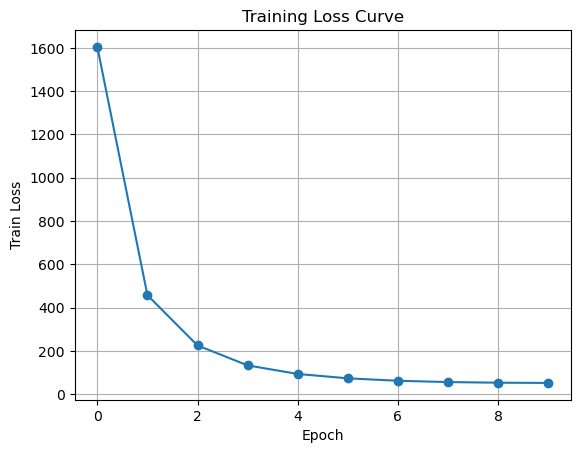

In [21]:
# =========================================
# 9. 학습 루프
# =========================================
examples = [
    "오늘 기분이 어때?",
    "너는 누구니?",
    "점심 뭐 먹을까?",
]

def sample_next_id(logits, temperature=0.8, top_k=20):
    """
    logits: (Vocab_Size,) 크기의 예측값
    temperature: 높을수록 창의적(무작위), 낮을수록 보수적(정확)
    top_k: 확률 상위 K개만 후보로 남김
    """
    # logits: (V,)
    logits = logits / temperature

    if top_k is not None and top_k > 0:
        values, indices = torch.topk(logits, top_k)          # 상위 k개
        probs = torch.zeros_like(logits)
        # 상위 k개 외에는 확률을 0으로 만들어버림 (Noise 제거)
        probs.scatter_(0, indices, F.softmax(values, dim=0)) # 나머지는 0
    else:
        probs = F.softmax(logits, dim=0)

    # 설정된 확률 분포를 바탕으로 다음 단어를 무작위 선택
    next_id = torch.multinomial(probs, num_samples=1).item()
    return next_id

def generate_with_attention(query, max_len=MAX_LEN):
    """입력 문장에 대해 답변을 생성하고 어텐션 맵을 반환합니다."""
    model.eval()
    with torch.no_grad():
        # 전처리 단계 (토큰화 -> 인코딩 -> 패딩)
        q_clean = clean_korean_text(query)
        q_tokens = kiwi_tokenize(q_clean)
        q_join = join_tokens(q_tokens)
        q_ids = encode_sentence(q_join)

        if len(q_ids) > max_len:
            q_ids = q_ids[:max_len]
        q_ids = q_ids + [0] * (max_len - len(q_ids))

        src = torch.tensor([q_ids], dtype=torch.long, device=device)

        out_ids = [1]  # 시작 토큰(BOS)으로 생성 시작

        # 반복 제어 변수 초기화
        repeat_cnt = 0
        max_repeat = 3
        window = 4

        for _ in range(max_len - 1):
            tgt_in = torch.tensor([out_ids], dtype=torch.long, device=device)
            enc_mask, dec_mask, encdec_mask = generate_masks(src, tgt_in)
            # 모델 예측
            logits, enc_attns, dec_attns, decenc_attns = model(
                src, tgt_in, enc_mask, dec_mask, encdec_mask
            )

            # top‑k + temperature 샘플링 - 마지막 타임스텝의 결과로 다음 단어 샘플링
            next_id = sample_next_id(
                logits[0, -1], temperature=0.8, top_k=20
            )

            # [반복 방지 로직] 최근 window 길이 안에 이미 등장한 토큰이면 반복 카운트
            recent = out_ids[-window:]
            if next_id in recent:
                repeat_cnt += 1
            else:
                repeat_cnt = 0

            # 종료 조건: EOS(2)가 나오거나, 무한 반복이 감지될 때
            if next_id == 2:  # EOS
                break
            if repeat_cnt >= max_repeat:
                break

            out_ids.append(next_id)

        # ID를 다시 텍스트로 변환
        decoded = tokenizer.DecodeIds(out_ids[1:])
        src_pieces = tokenizer.IdToPiece(q_ids)
        tgt_pieces = tokenizer.IdToPiece(out_ids[1:])
        return decoded, src_pieces, tgt_pieces, enc_attns, dec_attns, decenc_attns

# --- 본격적인 학습 시작 ---
epoch_losses = []

global_step = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    step = 0

    current_lr = scheduler.get_last_lr()[0]
    print(f"[Epoch {epoch}] lr(start) = {current_lr:.6e}")

    for src, tgt in tqdm(train_loader, desc=f"Epoch {epoch}"):
        src = src.to(device)
        tgt = tgt.to(device)

        # Teacher Forcing을 위해 입력(tgt_in)과 정답(tgt_out)을 1칸씩 밀어 생성
        tgt_in = tgt[:, :-1]    # <sos> ~ 단어_n-1
        tgt_out = tgt[:, 1:]    #  단어_1 ~ <eos>

        if step == 0 and epoch == 1:
            print("tgt_out min / max:", tgt_out.min().item(), tgt_out.max().item())
            print("VOCAB_SIZE:", VOCAB_SIZE)

        enc_mask, dec_mask, encdec_mask = generate_masks(src, tgt_in)

        base_optimizer.zero_grad()
        logits, _, _, _ = model(src, tgt_in, enc_mask, dec_mask, encdec_mask)

        loss = loss_function(tgt_out, logits)
        loss.backward()

        # 그래디언트 폭주 방지 (Gradient Clipping)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        base_optimizer.step()
        scheduler.step()  # 매 스텝마다 학습률 조정 ← 여기가 핵심[web:11][web:15]

        total_loss += loss.item()
        step += 1
        global_step += 1

    avg_loss = total_loss / step
    epoch_losses.append(avg_loss)
    print(f"[Epoch {epoch}] Train Loss: {avg_loss:.4f}")

    # 샘플 Q/A 출력
    print("=== 샘플 질의응답 ===")
    model.eval()
    for q in examples:
        ans, _, _, _, _, _ = generate_with_attention(q)
        print("Q:", q)
        print("A:", ans)
        print("----------------------")

# 손실 곡선
plt.figure()
plt.plot(epoch_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


### 10. BLEU 평가 + Attention 시각화

=== BLEU 예시 ===
Source : 12시 땡!
Target : 하루가 또 가네요.
Pred   : 아직 처럼턴 이 나 보 어 보 어
BLEU   : 0
Source : 1지망 학교 떨어졌어
Target : 위로해 드립니다.
Pred   : 아름답 을 사랑 하 어 있 는 는 는
BLEU   : 0
Source : 3박4일 놀러가고 싶다
Target : 여행은 언제나 좋죠.
Pred   : 아직 사귀 는 는 는
BLEU   : 0
Q: 오늘 기분이 어때?
A: 더 지 지 않 죠 .


/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45720 (\N{HANGUL SYLLABLE NEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/cond

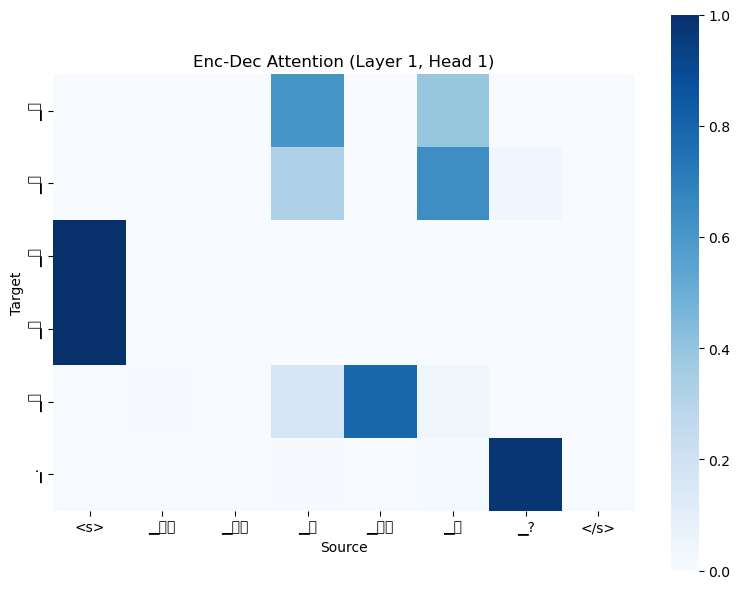

In [22]:
# =========================================
# 10. BLEU 평가 + Attention 시각화 예시
# =========================================
def eval_bleu_one(src_text, tgt_text, verbose=True):
    model.eval()
    pred, _, _, _, _, _ = generate_with_attention(src_text)
    ref = tgt_text.split()
    hyp = pred.split()
    smooth = SmoothingFunction().method1
    score = sentence_bleu([ref], hyp, smoothing_function=smooth)
    if verbose:
        print("Source :", src_text)
        print("Target :", tgt_text)
        print("Pred   :", pred)
        print("BLEU   :", score)
    return score

print("=== BLEU 예시 ===")
for i in range(3):
    src = df["Q_clean"].iloc[i]
    tgt = df["A_clean"].iloc[i]
    eval_bleu_one(src, tgt)

### Attention 시각화 1회 실행
q = "오늘 기분이 어때?"
pred, src_p, tgt_p, enc_attns, dec_attns, decenc_attns = generate_with_attention(q)
print("Q:", q)
print("A:", pred)
visualize_attention(src_p, tgt_p, enc_attns, dec_attns, decenc_attns)
# for l in range(len(decenc_attns)):
#     for h in range(decenc_attns[l].size(1)):
#         print(f"Layer {l+1}, Head {h+1}")
#         visualize_attention(src_p, tgt_p, enc_attns, dec_attns, decenc_attns, layer=l, head=h)
